# Team Stats
---

In [1]:
from matplotlib.ticker import FuncFormatter
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import beta
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("data/testingData.csv", low_memory=False)
df.head()

,Team-Match Key,Scouter Name,event key,match level,match number,alliance position,team number,start w/ coral,leave start,L1 auto,...,L3 teleop,L4 teleop,net teleop,processor teleop,pickup coral,final status,win/lose,arp,crp,brp
0,1.Red 1,aa,2025nyro,qm,1,Red 1,4638,True,0,4,...,2,1,0,0,s,d,0,False,True,True
1,1.Red 2,aa,2025nyro,qm,1,Red 2,5078,True,1,4,...,12,2,0,0,x,d,1,False,True,True
2,1.Red 3,aa,2025nyro,qm,1,Red 3,4662,True,1,20,...,8,9,0,1,b,s,1,False,True,True
3,1.Blue 1,aa,2025nyro,qm,1,Blue 1,214,True,0,0,...,1,0,0,0,x,d,1,False,True,True
4,1.Blue 2,aa,2025nyro,qm,1,Blue 2,1901,True,1,17,...,0,12,0,0,b,p,1,False,True,True


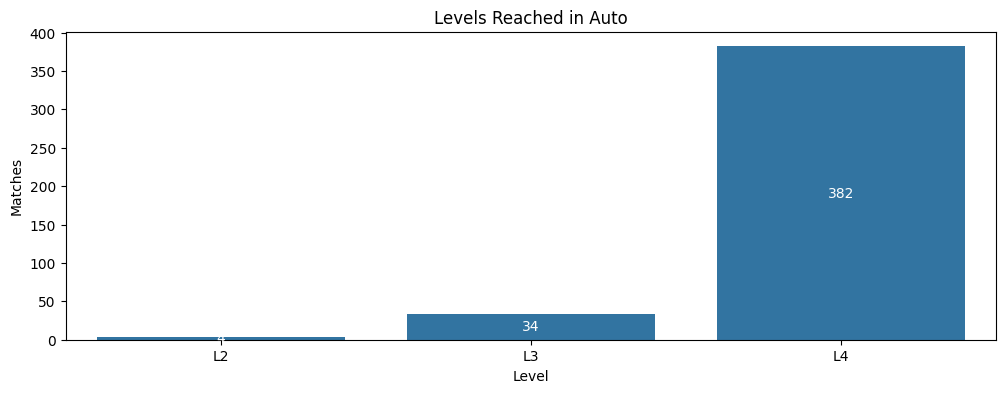

In [16]:
def scoreLevels(L1, L2, L3, L4):
    if L4>0:
        level = 'L4'
    elif L3>0:
        level = 'L3'
    elif L2>0:
        level = 'L2'
    elif L1>0:
        level = 'L1'
    else:
        level = 'x'
    return level



df['Level'] = df.apply(lambda row: scoreLevels(row['L1 auto'], row['L2 auto'], row['L3 auto'], row['L4 auto']), axis=1)

viz_data = df.groupby('Level').size().reset_index(name='Matches')

plt.figure(figsize=(12,4))
graph = sns.barplot(viz_data, x='Level', y='Matches')
# Give it a title that highlights the takeaway
graph.set_title('Levels Reached in Auto')
# Add the actual values to the chart
graph.bar_label(graph.containers[0], fmt='{:,.0f}', label_type='center', color='white')
# Add commas to the y-axis numbers
graph.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

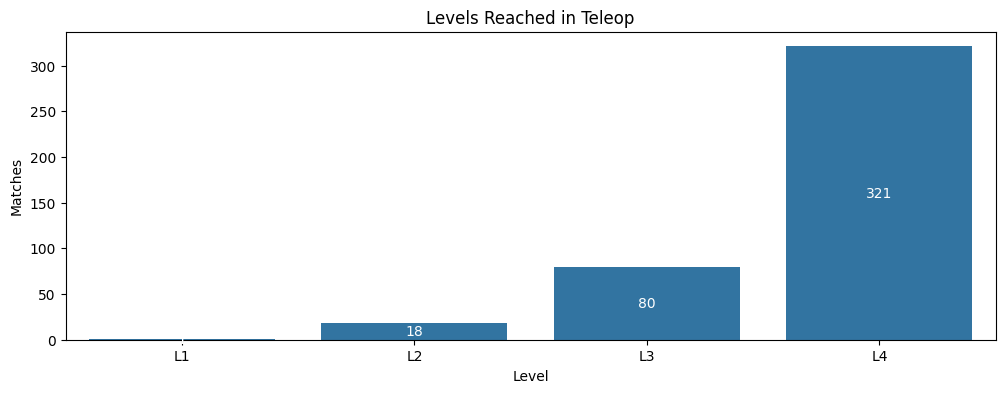

In [17]:
df['Level'] = df.apply(lambda row: scoreLevels(row['L1 teleop'], row['L2 teleop'], row['L3 teleop'], row['L4 teleop']), axis=1)

viz_data = df.groupby('Level').size().reset_index(name='Matches')

plt.figure(figsize=(12,4))
graph = sns.barplot(viz_data, x='Level', y='Matches')
# Give it a title that highlights the takeaway
graph.set_title('Levels Reached in Teleop')
# Add the actual values to the chart
graph.bar_label(graph.containers[0], fmt='{:,.0f}', label_type='center', color='white')
# Add commas to the y-axis numbers
graph.yaxis.set_major_formatter(FuncFormatter(lambda x, p: f'{int(x):,}'))

In [3]:
def highestLevel(L1a, L2a, L3a, L4a, L1t, L21, L3t, L4t):
    if L4a>0 or L4t>0:
        level = 'L4'
    elif L3a>0 or L3t>0:
        level = 'L3'
    elif L2a>0 or L3t>0:
        level = 'L2'
    elif L1a>0 or L1t>0:
        level = 'L1'
    else:
        level = 'x'
    return level

df['Level'] = df.apply(lambda row: highestLevel(row['L1 auto'], row['L2 auto'], row['L3 auto'], row['L4 auto'], row['L1 teleop'], row['L2 teleop'], row['L3 teleop'], row['L4 teleop']), axis=1)

df.head()

,Team-Match Key,Scouter Name,event key,match level,match number,alliance position,team number,start w/ coral,leave start,L1 auto,...,L4 teleop,net teleop,processor teleop,pickup coral,final status,win/lose,arp,crp,brp,Level
0,1.Red 1,aa,2025nyro,qm,1,Red 1,4638,True,0,4,...,1,0,0,s,d,0,False,True,True,L4
1,1.Red 2,aa,2025nyro,qm,1,Red 2,5078,True,1,4,...,2,0,0,x,d,1,False,True,True,L4
2,1.Red 3,aa,2025nyro,qm,1,Red 3,4662,True,1,20,...,9,0,1,b,s,1,False,True,True,L4
3,1.Blue 1,aa,2025nyro,qm,1,Blue 1,214,True,0,0,...,0,0,0,x,d,1,False,True,True,L4
4,1.Blue 2,aa,2025nyro,qm,1,Blue 2,1901,True,1,17,...,12,0,0,b,p,1,False,True,True,L4
